# Perform Feature Selection for GAM Model
## Setup Jupyter Notebook
### Import packages

In [1]:
# Import external packages
import pandas as pd
import os
import numpy as np
import random
import pyarrow.parquet as pq
import sys
import shutil
import pickle
import warnings
from itertools import chain

from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_percentage_error

from pygam import GAM, s, te, f, l

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import optuna
from optuna.visualization import matplotlib as optunampl

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 260)
warnings.filterwarnings("ignore")

In [2]:
# Import the internal package
package_loc = r"../"

# Add the package location to system paths
sys.path.append(package_loc)

from src import utils
from src.gam import training, explain

### Define Paths

In [21]:
###########################################################################
###########################################################################

data_version = "v2"
model_version = "v3"

###########################################################################
###########################################################################

# Define the directories for input and output
dir_input = f"input"
dir_data = f"export"
dir_output = f"output"

model_data_file = f"{dir_data}/gam_modelling_data_{data_version}.parquet"
modelling_log_02 = f"{dir_output}/02_model_note_{model_version}.xlsx"


print(os.listdir(dir_input))
print(os.listdir(dir_data))
print(os.listdir(dir_output))

['.gitkeep', 'CMI TA DB 2016 Datasheet v02 2024-06-17.xlsb', 'CMI TA DB 2017 Datasheet v02 2024-06-17.xlsb', 'CMI TA DB 2018 Datasheet v01 2022-05-20.xlsb', 'CMI TA DB 2019 Datasheet v01 2022-05-20.xlsb', 'CMI TA DB 2020 Datasheet v01 2022-05-20.xlsb']
['CMI Categorical Bands (with CalendarYear).xlsx', 'gam_modelling_data_v2.parquet']
['02_model_note_v3.xlsx', '03_model_note_v3.xlsx', 'gam_initial_v3.pkl', 'single_factor_rating_tables_v3.pkl', 'training_data_folds_v3.pkl']


### Set Variables

In [4]:
title_fontsize = 25
label_fontsize = 20
ticker_fontsize = 15

## Create Modelling Data

In [5]:
model_data = pd.read_parquet(f"{model_data_file}")
model_data

,ProductCategory,Gender,SmokerStatus,DistributionChannel,CommencementYear,JointLifeStatus,SumAssuredBand,Age,Duration,LivesExposure,AmountsExposure,IncurredClaims,AmountIncurred,ExpectedClaims,ExpectedAmountClaims,ComparatorTable,CalendarYear,holdout,random_fold,ProductCategory_cat_level,Gender_cat_level,SmokerStatus_cat_level,DistributionChannel_cat_level,JointLifeStatus_cat_level,CalendarYear_cat_level
unique_id,,,,,,,,,,,,,,,,,,,,,,,,,
0,Other,F,N,B,2001,J,4,49,10,0.986339,10791.699454,0.0,0.0,0.000838,9.172945,TFNL16,CY2016,0,3,2,0,0,0,0,0
1,Other,F,N,B,2003,J,4,43,10,0.415301,35692.456284,0.0,0.0,0.000206,17.667766,TFNL16,CY2016,0,1,2,0,0,0,0,0
2,Other,F,N,B,2003,J,4,44,10,0.584699,48133.442623,0.0,0.0,0.000317,26.088326,TFNL16,CY2016,0,4,2,0,0,0,0,0
3,Other,F,N,B,2003,S,4,51,10,0.581967,5756.663934,0.0,0.0,0.000589,5.825744,TFNL16,CY2016,0,2,2,0,0,0,1,0
4,Other,F,N,B,2003,S,5,38,10,0.461749,63719.904372,0.0,0.0,0.000148,20.390369,TFNL16,CY2016,0,1,2,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2535444,Level,M,S,U,2020,S,3,58,0,0.574863,53414.207650,0.0,0.0,0.001635,151.963421,TMSL16,CY2020,0,5,1,1,1,5,1,4
2535445,Level,M,S,U,2020,S,3,61,0,0.422951,42295.081967,0.0,0.0,0.001723,172.267869,TMSL16,CY2020,0,4,1,1,1,5,1,4
2535446,Level,M,S,U,2020,S,3,62,0,0.122951,13155.737705,0.0,0.0,0.000565,60.424303,TMSL16,CY2020,0,1,1,1,1,5,1,4


In [6]:
###########################################################################
###########################################################################

claim_count = "IncurredClaims"
claim_freq = "AnnualFreq"
weight = "LivesExposure"

# Define the list of numerical features
num_feat = [
    # "CommencementYear", # High correlation with Duration
    "SumAssuredBand",
    "Age",
    "Duration",
]

# Define the list of categorical features
cat_feat = [
    "ProductCategory_cat_level",
    "Gender_cat_level",
    "SmokerStatus_cat_level",
    "DistributionChannel_cat_level",
    "JointLifeStatus_cat_level",
    "CalendarYear_cat_level",
]

###########################################################################
###########################################################################

# Define the target for GAM
model_data[claim_freq] = model_data[claim_count] / model_data[weight]

# Define the full feature list
all_feat = num_feat + cat_feat
print(all_feat)

['SumAssuredBand', 'Age', 'Duration', 'ProductCategory_cat_level', 'Gender_cat_level', 'SmokerStatus_cat_level', 'DistributionChannel_cat_level', 'JointLifeStatus_cat_level', 'CalendarYear_cat_level']


In [7]:
# Check the number of rows with null target
print(model_data[model_data[claim_freq].isnull()].shape[0])

1192


In [ ]:
# Null values in the target are caused by zero exposure in the data
model_data[model_data[claim_freq].isnull()].head()

In [ ]:
# Need to remove rows with 0 exposures
model_data = model_data[
    ~((model_data[claim_freq].isnull()) | (model_data[claim_freq] == np.inf))
]
model_data

In [10]:
# Count null values for all columns
model_data.isnull().sum()

ProductCategory                  0
Gender                           0
SmokerStatus                     0
DistributionChannel              0
CommencementYear                 0
JointLifeStatus                  0
SumAssuredBand                   0
Age                              0
Duration                         0
LivesExposure                    0
AmountsExposure                  0
IncurredClaims                   0
AmountIncurred                   0
ExpectedClaims                   0
ExpectedAmountClaims             0
ComparatorTable                  0
CalendarYear                     0
holdout                          0
random_fold                      0
ProductCategory_cat_level        0
Gender_cat_level                 0
SmokerStatus_cat_level           0
DistributionChannel_cat_level    0
JointLifeStatus_cat_level        0
CalendarYear_cat_level           0
AnnualFreq                       0
dtype: int64

### Define required dataframes

In [11]:
###########################################################################
###########################################################################

training_folds_files = f"{dir_output}/training_data_folds_{model_version}.pkl"

###########################################################################
###########################################################################

with open(f"{dir_output}/training_data_folds_{model_version}.pkl", "rb") as file:
    X_train_rs, y_train_rs, w_train_rs, folds, base_adj = pickle.load(file)

print(f"Base Adjustment: {base_adj:.4f}")

Base Adjustment: 0.7744


In [12]:
###########################################################################
###########################################################################

holdout = "holdout"
random_fold = "random_fold"
num_fold = 5  # Number of folds in the training data

###########################################################################
###########################################################################

X_test = model_data.loc[model_data[holdout] == 1, all_feat]
y_test = model_data.loc[model_data[holdout] == 1, claim_freq]
w_test = model_data.loc[model_data[holdout] == 1, weight]

In [13]:
# Create a term string for GAM training
term_string, num_feat_map, cat_feat_map, _ = training.create_term_structure(
    num_feat,
    cat_feat,
    X_train_rs,
)
print(term_string)

s(0, lam=lam_num, n_splines=n_splines)+ s(1, lam=lam_num, n_splines=n_splines)+ s(2, lam=lam_num, n_splines=n_splines) + f(3, lam=lam_cat) + f(4, lam=lam_cat) + f(5, lam=lam_cat) + f(6, lam=lam_cat) + f(7, lam=lam_cat) + f(8, lam=lam_cat)


In [ ]:
# In any unseen data, any categorical level not in the training set will be mapped to the mode of the training set
for v in cat_feat:
    unique_level = X_train_rs[v].unique()
    condition = X_test[v].isin(unique_level)
    X_test[v] = np.where(condition, X_test[v], X_train_rs[v].mode().iloc[0])
X_test

In [15]:
# Create training and validation sets for each permutation of the random folds
X_train_cv = {}
X_valid_cv = {}
w_train_cv = {}
w_valid_cv = {}
y_train_cv = {}
y_valid_cv = {}

for i, (train_index, valid_index) in enumerate(folds):
    X_train_cv[i] = X_train_rs.iloc[train_index]
    X_valid_cv[i] = X_train_rs.iloc[valid_index]

    # Any unseen level in the validation fold needs to be replaced by the mode in the training folds
    for v in cat_feat_map.values():
        unique_level = X_train_cv[i][v].unique()
        condition = X_valid_cv[i][v].isin(unique_level)
        X_valid_cv[i][v] = np.where(
            condition, X_valid_cv[i][v], X_train_cv[i][v].mode().iloc[0]
        )

    w_train_cv[i] = w_train_rs.iloc[train_index]
    w_valid_cv[i] = w_train_rs.iloc[valid_index]
    y_train_cv[i] = y_train_rs.iloc[train_index]
    y_valid_cv[i] = y_train_rs.iloc[valid_index]

## Load Parameters and Calculate Metrics

In [24]:
###########################################################################
###########################################################################

modelling_log_02 = f"{dir_output}/02_model_note_{model_version}.xlsx"

###########################################################################
###########################################################################

study_df = pd.read_excel(f"{modelling_log_02}", "Initial_Tune")
best_params = study_df.sort_values("value").filter(regex="params_").iloc[0].to_dict()
best_params = {k.replace("params_", ""): v for k, v in best_params.items()}

n_splines = int(best_params["n_splines"])
lam_num = best_params["lam_num"]
lam_cat = best_params["lam_cat"]

param_dict = {"n_splines": n_splines, "lam_num": lam_num, "lam_cat": lam_cat}

print(f"n_splines: {n_splines}")
print(f"lam_num: {lam_num}")
print(f"lam_cat: {lam_cat}")

n_splines: 9
lam_num: 1.701354643588326
lam_cat: 30.08867923762384


In [25]:
###########################################################################
###########################################################################

filename = f"{dir_output}/gam_initial_{model_version}.pkl"

###########################################################################
###########################################################################

# Re-load the GAM model
with open(filename, "rb") as file:
    gam_model = pickle.load(file)

print(f"Total effective degrees of freedom: {gam_model.statistics_['edof']:.2f}")

Total effective degrees of freedom: 32.05


In [ ]:
###########################################################################
###########################################################################

new_model_freq = "gam_freq"
cmi_base = "ExpectedClaims"
cmi_freq = "cmi_freq"
new_model_count = "gam_claim_count"

###########################################################################
###########################################################################

ypred_train = gam_model.predict(X_train_rs)

ypred_train_df = pd.DataFrame(
    ypred_train, columns=[new_model_freq], index=X_train_rs.index
)

ypred_train_df = (
    ypred_train_df.join(y_train_rs)
    .join(w_train_rs)
    .join(
        model_data[
            [
                claim_count,
            ]
        ]
    )
)
ypred_train_df[new_model_count] = (
    ypred_train_df[new_model_freq] * ypred_train_df[weight]
)
ypred_train_df

In [27]:
# Poisson Deviance and Bayesian Information Criterion (BIC)
gam_dev = utils.total_poisson_dev(
    y=ypred_train_df[claim_count],
    y_pred=ypred_train_df[new_model_count],
)
bic_poisson = gam_dev + gam_model.statistics_["edof"] * np.log(len(ypred_train_df))

print(f"{'Poisson Deviance':<40}: {gam_dev:,.0f}")
print(f"{'Bayesian Information Criterion (BIC)':<40}: {bic_poisson:,.0f}")

Poisson Deviance                        : 193,579
Bayesian Information Criterion (BIC)    : 194,035


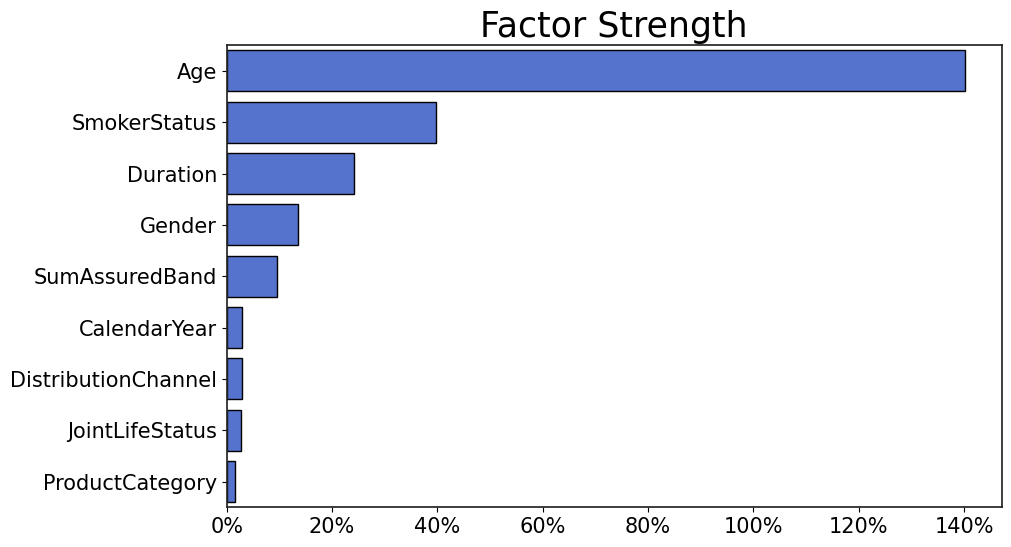

In [28]:
##########################################################################
##########################################################################

# Load in the factor importance results from the prior modelling log
fact_imp_df = pd.read_excel(f"{modelling_log_02}", "Sing_Fac_Imp")

##########################################################################
##########################################################################

plt.rcParams["figure.figsize"] = [10, 6]
fig, ax = plt.subplots(1)
plt.rcParams["axes.edgecolor"] = "0.15"
plt.rcParams["axes.linewidth"] = 1.25

# Plot data
sns.barplot(
    x="factor_strength",
    y="feature",
    data=fact_imp_df,
    ax=ax,
    color="royalblue",
    edgecolor="black",
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0%}"))
ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)

ax.set_title(
    f"Factor Strength",
    fontsize=title_fontsize,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)
ax.set_facecolor("white")

## Factor Pruning

In [29]:
###########################################################################
###########################################################################

# Define the directory for the categorical mapping spreadsheet
cat_map_table = f"{dir_data}/CMI Categorical Bands (with CalendarYear).xlsx"
# Define hyperparameters retuning frequency
retune = 2

###########################################################################
###########################################################################

# Initiate a dataframe to track progress during pruning
factor_prune_df = pd.DataFrame(range(fact_imp_df.shape[0]), columns=["iter"])
factor_prune_df["bic_poisson"] = np.nan
factor_prune_df["num_factors"] = np.nan

factor_prune_df.loc[0, ["bic_poisson"]] = bic_poisson
factor_prune_df.loc[0, ["num_factors"]] = len(fact_imp_df)

factorlist = fact_imp_df["feature"]
numfacs = len(factorlist)

factor_prune_df[list(param_dict.keys())] = np.nan
factor_prune_df.loc[0, list(param_dict.keys())] = list(param_dict.values())

# initialise a container to track the factors dropped
factorstracking = []
factorstracking.append(factorlist.to_list())

params_prune = param_dict.copy()
lam_num = params_prune["lam_num"]
lam_cat = params_prune["lam_cat"]
n_splines = params_prune["n_splines"]

for i in range(numfacs):
    if len(factorlist) == 1:
        break

    variable_list = factorlist.to_list()
    # Number of factors to drop for each iteration
    drop_num = 1

    variable_list = variable_list[: len(factorlist) - drop_num]
    variable_list = [
        x + "_cat_level" if x + "_cat_level" in cat_feat else x for x in variable_list
    ]
    print("=" * 100)
    print(f"Iteration {i+1}: Number of features: {len(variable_list)} ")

    # Define the feature dataframe
    X_train_prune = X_train_rs[variable_list]
    # Re-define the list of numerical variables
    num_feat_prune = list(set(num_feat).intersection(set(variable_list)))
    # Re-define the list of categorical variables
    cat_feat_prune = list(set(cat_feat).intersection(set(variable_list)))
    # Define the term string for model training
    (
        term_string_prune,
        num_feat_map_prune,
        cat_feat_map_prune,
        _,
    ) = training.create_term_structure(
        num_feat_prune,
        cat_feat_prune,
        X_train_prune,
    )

    X_train_prune_cv = {}
    X_valid_prune_cv = {}

    for j, (train_idx, valid_idx) in enumerate(folds):
        X_train_prune_cv[j] = X_train_prune.iloc[train_idx]
        X_valid_prune_cv[j] = X_train_prune.iloc[valid_idx]

        for var in cat_feat_prune:
            unique_level = X_train_prune_cv[j][var].unique()
            condition = X_valid_prune_cv[j][var].isin(unique_level)
            X_valid_prune_cv[j][var] = np.where(
                condition,
                X_valid_prune_cv[j][var],
                X_train_prune_cv[j][var].mode().iloc[0],
            )

    # Periodically re-tune hyperparameters
    if i % retune == 0 and i > 0:
        n_splines_range = (
            max(params_prune["n_splines"] - 1, 4),
            params_prune["n_splines"] + 1,
        )
        lam_num_range = (
            max(params_prune["lam_num"] / 10, 1),
            params_prune["lam_num"] * 10,
            True,
        )
        lam_cat_range = (
            max(params_prune["lam_cat"] / 10, 1),
            params_prune["lam_cat"] * 10,
            True,
        )

        # create study
        study = optuna.create_study(direction="minimize")

        # define objective
        objective = training.OptunaGamObjectiveCV(
            term_string_prune,
            5,
            n_splines_range,
            lam_num_range,
            lam_cat_range,
            X_train_prune_cv,
            X_valid_prune_cv,
            y_train_cv,
            y_valid_cv,
            w_train_cv,
            w_valid_cv,
        )
        study.optimize(objective, n_trials=15)
        params_prune = study.best_params
        lam_num = params_prune["lam_num"]
        lam_cat = params_prune["lam_cat"]
        n_splines = params_prune["n_splines"]
        params_prune = {k: v for k, v in params_prune.items() if k in param_dict.keys()}

    # Fit the GAM model
    gam_model_prune = GAM(
        eval(term_string_prune),
        distribution="poisson",
        link="log",
    ).fit(X_train_prune, y_train_rs, weights=w_train_rs)

    # Initilise an empty dictionary for numerical variables
    num_rel_dict_prune, _ = training.extract_gam_relativity_num(
        gam_model_prune,
        X_train_prune,
        w_train_rs,
        num_feat_map_prune,
        weight,
        intercept_adj_list=[],
    )

    cat_rel_dict_prune, _ = training.extract_gam_relativity_cat(
        gam_model_prune,
        X_train_prune,
        w_train_rs,
        cat_feat_map_prune,
        weight,
        cat_map_table, 
        intercept_adj_list=[],
    )

    fact_imp_prune_df, _ = explain.factor_strength(
        num_rel_dict_prune, cat_rel_dict_prune, weight=weight
    )

    # Get the predictions on the training data
    ypred_train_prune = gam_model_prune.predict(X_train_prune)

    ypred_train_df_prune = pd.DataFrame(
        ypred_train_prune, columns=[new_model_freq], index=X_train_prune.index
    )

    ypred_train_df_prune = (
        ypred_train_df_prune.join(y_train_rs)
        .join(w_train_rs)
        .join(
            model_data[
                [
                    claim_count,
                ]
            ]
        )
    )
    ypred_train_df_prune[new_model_count] = (
        ypred_train_df_prune[new_model_freq] * ypred_train_df_prune[weight]
    )
    # Calculate the Poisson deviance
    gam_dev_prune = utils.total_poisson_dev(
        y=ypred_train_df_prune[claim_count],
        y_pred=ypred_train_df_prune[new_model_count],
    )
    # Calculate the Bayesian Information Criterion (BIC)
    bic_poisson_prune = gam_dev_prune + gam_model_prune.statistics_["edof"] * np.log(
        len(ypred_train_df_prune)
    )

    factorlist = fact_imp_prune_df["feature"]
    factorlist2 = np.full(numfacs, np.nan, dtype="object")
    factorlist2[: len(factorlist)] = factorlist
    factorstracking.append(factorlist2)

    factor_prune_df.loc[i + 1, ["bic_poisson"]] = bic_poisson_prune
    factor_prune_df.loc[i + 1, ["num_factors"]] = len(factorlist)
    factor_prune_df.loc[i + 1, list(params_prune.keys())] = list(params_prune.values())
    print(f"BIC (Poisson) in iteration {i + 1}: {bic_poisson_prune:,.0f}", sep="; ")

Iteration 1: Number of features: 8 
BIC (Poisson) in iteration 1: 194,002
Iteration 2: Number of features: 7 
BIC (Poisson) in iteration 2: 194,005
Iteration 3: Number of features: 6 


[I 2026-04-08 12:37:56,573] A new study created in memory with name: no-name-b34f3492-5b3d-4e68-930b-a47ef1cfe364
[I 2026-04-08 12:41:28,929] Trial 0 finished with value: 193687.62596354436 and parameters: {'n_splines': 8, 'lam_num': 4.785213630120648, 'lam_cat': 56.1015611144122, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 193687.62596354436.
[I 2026-04-08 12:45:24,669] Trial 1 finished with value: 193688.3388090031 and parameters: {'n_splines': 9, 'lam_num': 5.615095458476347, 'lam_cat': 5.1604921010034035, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 193687.62596354436.
[I 2026-04-08 12:50:16,713] Trial 2 finished with value: 193688.50098584016 and parameters: {'n_splines': 10, 'lam_num': 3.7403274220540745, 'lam_cat': 78.08891301617612, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 193687.62596354436.
[I 2026-04-08 12:54:35,174] Trial

BIC (Poisson) in iteration 3: 193,983
Iteration 4: Number of features: 5 
BIC (Poisson) in iteration 4: 193,960
Iteration 5: Number of features: 4 


[I 2026-04-08 13:48:50,513] A new study created in memory with name: no-name-69be9f8f-8ca2-4c85-8a12-99f08c7d00f1
[I 2026-04-08 13:51:34,855] Trial 0 finished with value: 194033.87853653857 and parameters: {'n_splines': 9, 'lam_num': 8.348798551898739, 'lam_cat': 27.39186361503651, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 194033.87853653857.
[I 2026-04-08 13:54:18,708] Trial 1 finished with value: 194034.73952804768 and parameters: {'n_splines': 9, 'lam_num': 9.965349243454957, 'lam_cat': 72.60693158989544, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 194033.87853653857.
[I 2026-04-08 13:57:17,067] Trial 2 finished with value: 194033.49671995325 and parameters: {'n_splines': 10, 'lam_num': 2.5966836579904657, 'lam_cat': 119.88541996584404, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 2 with value: 194033.49671995325.
[I 2026-04-08 14:00:11,500] Tri

BIC (Poisson) in iteration 5: 194,208
Iteration 6: Number of features: 3 
BIC (Poisson) in iteration 6: 194,761
Iteration 7: Number of features: 2 


[I 2026-04-08 14:40:45,846] A new study created in memory with name: no-name-7b8cb6ad-b2f6-41fd-8db8-a3a216de8c53
[I 2026-04-08 14:42:53,414] Trial 0 finished with value: 196189.57908743247 and parameters: {'n_splines': 9, 'lam_num': 6.1524322169829775, 'lam_cat': 2.839557346729684, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 196189.57908743247.
[I 2026-04-08 14:44:41,137] Trial 1 finished with value: 196191.74599017532 and parameters: {'n_splines': 7, 'lam_num': 5.688841347844173, 'lam_cat': 4.155898011225913, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 196189.57908743247.
[I 2026-04-08 14:46:51,414] Trial 2 finished with value: 196188.39616125321 and parameters: {'n_splines': 9, 'lam_num': 3.4916673818106223, 'lam_cat': 2.9461643183895934, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 2 with value: 196188.39616125321.
[I 2026-04-08 14:49:01,921] Tri

BIC (Poisson) in iteration 7: 196,284
Iteration 8: Number of features: 1 
BIC (Poisson) in iteration 8: 201,626


Text(0, 0.5, '')

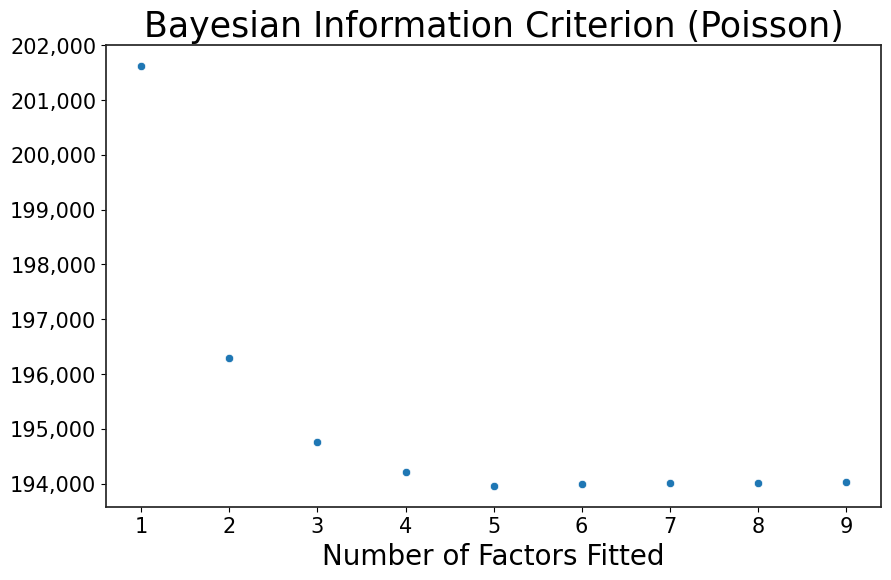

In [30]:
plt.rcParams["figure.figsize"] = [10, 6]
fig, ax = plt.subplots(1)
plt.rcParams["axes.edgecolor"] = "0.15"
plt.rcParams["axes.linewidth"] = 1.25

sns.scatterplot(
    data=factor_prune_df, x="num_factors", y="bic_poisson", ax=ax, color=["tab:blue"]
)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)
ax.grid(False)
ax.set_facecolor("white")

ax.set_title("Bayesian Information Criterion (Poisson)", fontsize=title_fontsize)
ax.set_xlabel("Number of Factors Fitted", fontsize=label_fontsize)
ax.set_ylabel("")

In [31]:
factor_prune_df[
    (factor_prune_df["bic_poisson"] == factor_prune_df["bic_poisson"].min())
]

,iter,bic_poisson,num_factors,n_splines,lam_num,lam_cat
4,4,193960.383958,5.0,9.0,1.482841,17.69048


In [32]:
# Define the iteration that min the cv score
iter_min = factor_prune_df[
    (factor_prune_df["bic_poisson"] == factor_prune_df["bic_poisson"].min())
].iloc[0, 0]
factorstracking_df = pd.DataFrame(factorstracking)

# Check the set of factors that minimises the deviance loss
factor = factorstracking_df.iloc[iter_min][
    ~factorstracking_df.iloc[iter_min].isnull()
].to_list()

print("Minimum BIC achieved with the following factors:")
print(f"Number of factors: {len(factor)}")
print(factor)

Minimum BIC achieved with the following factors:
Number of factors: 5
['Age', 'SmokerStatus', 'Duration', 'Gender', 'SumAssuredBand']


In [33]:
iter_ = factor_prune_df[factor_prune_df["num_factors"] == 5].iloc[0, 0]

# Check another set of factors
factor = factorstracking_df.iloc[iter_][
    ~factorstracking_df.iloc[iter_].isnull()
].to_list()

print(f"Number of factors: {len(factor)}")
print(factor)

Number of factors: 5
['Age', 'SmokerStatus', 'Duration', 'Gender', 'SumAssuredBand']


In [34]:
###########################################################################
###########################################################################

modelling_log = f"{dir_output}/03_model_note_{model_version}.xlsx"

###########################################################################
###########################################################################

with pd.ExcelWriter(f"{modelling_log}", engine="openpyxl", mode="w") as writer:
    factorstracking_df.to_excel(writer, sheet_name="Factors_Used", index=False)
    factor_prune_df.to_excel(writer, sheet_name="Prune_Progress", index=False)